In [ ]:
%%bash
#cpu
conda create --name DeepMEL_conda_env_cpu_lc python=3.6 tensorflow=1.14.0 keras=2.2.4
conda activate DeepMEL_conda_env_cpu
conda install main::shap
conda install numpy=1.16.2 matplotlib=3.1.1 ipykernel=5.1.2

#gpu
conda create --name DeepMEL_conda_env_gpu python=3.6 tensorflow-gpu=1.14.0 keras-gpu=2.2.4
conda activate DeepMEL_conda_env_gpu
conda install main::shap
conda install numpy=1.16.2  matplotlib=3.1.1 ipykernel=5.1.2

#### Loading necessary packages

In [1]:
import sys
import optparse
from array import *

import tensorflow
import numpy as np

import matplotlib
#matplotlib.use('pdf')
import matplotlib.pyplot as plt

import sklearn
from sklearn.utils import class_weight, shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, roc_auc_score

from keras.models import Sequential
from keras.models import model_from_json
from keras.layers.core import Dense, Dropout, Activation, Flatten
from keras.layers.convolutional import Conv1D, MaxPooling1D
from keras.layers import Bidirectional, Concatenate, PReLU 
from keras.optimizers import RMSprop, Adam
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras import regularizers
from keras.layers.wrappers import Bidirectional, TimeDistributed
from keras.layers.recurrent import LSTM
from keras.layers import Layer, average, Input
from keras.models import Model
from keras.utils import plot_model

/mnt/public5/genomebench/miniconda3/envs/DeepMEL_conda_env_cpu_lc/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/mnt/public5/genomebench/miniconda3/envs/DeepMEL_conda_env_cpu_lc/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/mnt/public5/genomebench/miniconda3/envs/DeepMEL_conda_env_cpu_lc/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _n

In [2]:
print("Tensorflow version: " + tensorflow.__version__)
foldername = 'results/'
NUM_CLASSES = 24
selected_classes = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24])-1
SEQ_LEN = 500
SEQ_DIM = 4
seq_shape = (SEQ_LEN, SEQ_DIM)
EPOCH = 2
BATCH = 128

Tensorflow version: 1.14.0


In [5]:
###########生成随机的数据
import numpy as np
import random
import os

def generate_random_fasta(filename, num_sequences, seq_len=500, num_classes=24, 
                          prefix="seq", chromosome=None, append_mode=False):
    """
    生成随机 FASTA 文件，格式符合 DeepMEL 要求
    
    参数:
        filename: 输出文件名
        num_sequences: 序列数量
        seq_len: 序列长度（默认500）
        num_classes: 类别数（默认24）
        prefix: 序列ID前缀
        chromosome: 如果指定（如'chr1'），会作为ID前缀
        append_mode: 是否追加模式（False=覆盖写入，True=追加写入）
    """
    bases = ['A', 'C', 'G', 'T']
    
    # 创建文件所在目录（如果不存在）
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    
    # 选择写入模式
    mode = 'a' if append_mode else 'w'
    
    with open(filename, mode) as f:
        for i in range(num_sequences):
            # 随机选择一个类别（1~24）
            topic_id = np.random.randint(1, num_classes + 1)
            
            # 生成序列ID
            if chromosome:
                seq_id = f"{chromosome}:{i*1000}-{i*1000+seq_len}_{topic_id}"
            else:
                seq_id = f"{prefix}_{i}_{topic_id}"
            
            # 生成随机序列
            sequence = ''.join(random.choice(bases) for _ in range(seq_len))
            
            # 写入 FASTA
            f.write(f">{seq_id}\n")
            f.write(f"{sequence}\n")
    
    action = "Appended" if append_mode else "Generated (overwritten)"
    print(f"{action} {num_sequences} sequences -> {filename}")

# ========== 生成训练、验证、测试集 ==========

# 训练集：不含 chr2 和 chr11（生成多个染色体）
# 先清空文件（覆盖模式写入第一个染色体）
train_filename = 'data/summits_to_topics_wochr2_wochr11.fa'
chromosomes_for_train = ['chr1', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 
                         'chr8', 'chr9', 'chr10', 'chr12', 'chr13', 'chr14',
                         'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr20', 
                         'chr21', 'chr22', 'chrX', 'chrY']
sequences_per_chrom = 4400 // len(chromosomes_for_train)

# 第一个染色体使用覆盖模式（创建/清空文件）
generate_random_fasta(train_filename, 
                     num_sequences=sequences_per_chrom, 
                     chromosome=chromosomes_for_train[0],
                     append_mode=False)

# 其余染色体使用追加模式
for chrom in chromosomes_for_train[1:]:
    generate_random_fasta(train_filename, 
                         num_sequences=sequences_per_chrom, 
                         chromosome=chrom,
                         append_mode=True)

# 验证集：chr11（覆盖模式，创建新文件）
generate_random_fasta('data/summits_to_topics_chr11.fa', 
                      num_sequences=200, 
                      chromosome='chr11',
                      append_mode=False)

# 测试集：chr2（覆盖模式，创建新文件）
generate_random_fasta('data/summits_to_topics_chr2.fa', 
                      num_sequences=200, 
                      chromosome='chr2',
                      append_mode=False)

print("\n所有文件生成完成！")

Generated (overwritten) 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topics_wochr2_wochr11.fa
Appended 200 sequences -> data/summits_to_topic

#### Defining necessary functitons

In [3]:
def get_output(input_layer, hidden_layers):
    output = input_layer
    for hidden_layer in hidden_layers: 
        output = hidden_layer(output)
    return output

def build_model():
    forward_input = Input(shape=seq_shape)
    reverse_input = Input(shape=seq_shape)

    hidden_layers = [
        Conv1D(128, kernel_size=20, padding="valid", activation='relu', kernel_initializer='random_uniform'),
        MaxPooling1D(pool_size=10, strides=10, padding='valid'),
        Dropout(0.2),
        TimeDistributed(Dense(128, activation='relu')),
        Bidirectional(LSTM(128, dropout=0.1, recurrent_dropout=0.1, return_sequences=True)),
        Dropout(0.2),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(len(selected_classes), activation='sigmoid')]
    forward_output = get_output(forward_input, hidden_layers)     
    reverse_output = get_output(reverse_input, hidden_layers)
    output = average([forward_output, reverse_output])
    model = Model(input=[forward_input, reverse_input], output=output)

    model.summary()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def readfile(filename):
    ids = []
    ids_d = {}
    seqs = {}
    classes = {}
    f = open(filename, 'r')
    lines = f.readlines()
    f.close()
    seq = []
    for line in lines:
        if line[0] == '>':
            ids.append(line[1:].rstrip('\n'))
            if line[1:].rstrip('\n').split('_')[0] not in seqs:
                seqs[line[1:].rstrip('\n').split('_')[0]] = []
            if line[1:].rstrip('\n').split('_')[0] not in ids_d:
                ids_d[line[1:].rstrip('\n').split('_')[0]] = line[1:].rstrip('\n').split('_')[0]
            if line[1:].rstrip('\n').split('_')[0] not in classes:
                classes[line[1:].rstrip('\n').split('_')[0]] = np.zeros(NUM_CLASSES)
            classes[line[1:].rstrip('\n').split('_')[0]][int(line[1:].rstrip('\n').split('_')[1])-1] = 1        
            if seq != []: seqs[ids[-2].split('_')[0]]= ("".join(seq))
            seq = []
        else:
            seq.append(line.rstrip('\n').upper())
    if seq != []:
        seqs[ids[-1].split('_')[0]]=("".join(seq))
    return ids,ids_d,seqs,classes

def one_hot_encode_along_row_axis(sequence):
    to_return = np.zeros((1,len(sequence),4), dtype=np.int8)
    seq_to_one_hot_fill_in_array(zeros_array=to_return[0],
                                 sequence=sequence, one_hot_axis=1)
    return to_return

def seq_to_one_hot_fill_in_array(zeros_array, sequence, one_hot_axis):
    assert one_hot_axis==0 or one_hot_axis==1
    if (one_hot_axis==0):
        assert zeros_array.shape[1] == len(sequence)
    elif (one_hot_axis==1): 
        assert zeros_array.shape[0] == len(sequence)
    for (i,char) in enumerate(sequence):
        if (char=="A" or char=="a"):
            char_idx = 0
        elif (char=="C" or char=="c"):
            char_idx = 1
        elif (char=="G" or char=="g"):
            char_idx = 2
        elif (char=="T" or char=="t"):
            char_idx = 3
        elif (char=="N" or char=="n"):
            continue
        else:
            raise RuntimeError("Unsupported character: "+str(char))
        if (one_hot_axis==0):
            zeros_array[char_idx,i] = 1
        elif (one_hot_axis==1):
            zeros_array[i,char_idx] = 1

def create_plots(history):
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig(foldername + 'accuracy.png')
    plt.clf()

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.savefig(foldername + 'loss.png')
    plt.clf()
    
def json_hdf5_to_model(json_filename, hdf5_filename):  
    with open(json_filename, 'r') as f:
        model = model_from_json(f.read())
    model.load_weights(hdf5_filename)
    return model

def loc_to_model_loss(loc):
    return json_hdf5_to_model(loc + 'model.json', loc + 'model_best_loss.hdf5')

def shuffle_label(label):
    for i in range(len(label.T)):
        label.T[i] = shuffle(label.T[i])
    return label

def calculate_roc_pr(score, label):
    output = np.zeros((len(label.T), 2))
    for i in range(len(label.T)):
        roc_ = roc_auc_score(label.T[i], score.T[i])
        pr_ = average_precision_score(label.T[i], score.T[i])
        output[i] = [roc_, pr_]
    return output

#### Preparing the input data

In [4]:



train_filename = 'data/summits_to_topics_wochr2_wochr11.fa'
valid_filename = 'data/summits_to_topics_chr11.fa'
test_filename = 'data/summits_to_topics_chr2.fa'

PATH_TO_SAVE_ARC = foldername + 'model.json'
PATH_TO_SAVE_BEST_LOST_WEIGHTS = foldername + 'model_best_loss.hdf5'
PATH_TO_SAVE_BEST_ACC_WEIGHTS = foldername + 'model_best_acc.hdf5'
PATH_TO_SAVE_END_WEIGHTS = foldername + 'model_end.hdf5'

print("Prepare input...")
train_ids, train_ids_d, train_seqs, train_classes = readfile(train_filename)
X_train = np.array([one_hot_encode_along_row_axis(train_seqs[id]) for id in train_ids_d]).squeeze(axis=1)
y_train = np.array([train_classes[id] for id in train_ids_d])
y_train = y_train[:,selected_classes]
X_train = X_train[y_train.sum(axis=1)>0]
y_train = y_train[y_train.sum(axis=1)>0]
X_train_rc = X_train[:,::-1,::-1]
train_data = [X_train, X_train_rc]

valid_ids, valid_ids_d, valid_seqs, valid_classes = readfile(valid_filename)
X_valid = np.array([one_hot_encode_along_row_axis(valid_seqs[id]) for id in valid_ids_d]).squeeze(axis=1)
y_valid = np.array([valid_classes[id] for id in valid_ids_d])
y_valid = y_valid[:,selected_classes]
X_valid = X_valid[y_valid.sum(axis=1)>0]
y_valid = y_valid[y_valid.sum(axis=1)>0]
X_valid_rc = X_valid[:,::-1,::-1]
valid_data = [X_valid, X_valid_rc]

test_ids, test_ids_d, test_seqs, test_classes = readfile(test_filename)
X_test = np.array([one_hot_encode_along_row_axis(test_seqs[id]) for id in test_ids_d]).squeeze(axis=1)
y_test = np.array([test_classes[id] for id in test_ids_d])
y_test = y_test[:,selected_classes]
X_test = X_test[y_test.sum(axis=1)>0]
y_test = y_test[y_test.sum(axis=1)>0]
X_test_rc = X_test[:,::-1,::-1]
test_data = [X_test, X_test_rc]

Prepare input...


#### Training the model

In [9]:

EPOCH=5
print("Compile model...")
model = build_model()

model_json = model.to_json()
with open(PATH_TO_SAVE_ARC, "w") as json_file:
    json_file.write(model_json)
print("Model architecture saved to..", PATH_TO_SAVE_ARC)

checkpoint1 = ModelCheckpoint(PATH_TO_SAVE_BEST_LOST_WEIGHTS, monitor='val_loss', verbose=1, save_best_only=True, mode='min')
checkpoint2 = ModelCheckpoint(PATH_TO_SAVE_BEST_ACC_WEIGHTS, monitor='val_acc', verbose=1, save_best_only=True, mode='max')
checkpoint3 = EarlyStopping(monitor='val_loss', patience=6)
callbacks_list = [checkpoint1, checkpoint2, checkpoint3]

print("Train model...")
history = model.fit( train_data, y_train, nb_epoch=EPOCH, batch_size=BATCH, shuffle=True, validation_data=(valid_data, y_valid),  verbose=1, callbacks= callbacks_list)
create_plots(history)
model.save_weights(PATH_TO_SAVE_END_WEIGHTS)
print("Model weights saved to..", PATH_TO_SAVE_END_WEIGHTS)
#plot_model(model, to_file=foldername + 'model.png')


Compile model...


/mnt/public5/genomebench/miniconda3/envs/DeepMEL_conda_env_cpu_lc/lib/python3.6/site-packages/ipykernel_launcher.py:25: UserWarning: Update your `Model` call to the Keras 2 API: `Model(inputs=[<tf.Tenso..., outputs=Tensor("av...)`
/mnt/public5/genomebench/miniconda3/envs/DeepMEL_conda_env_cpu_lc/lib/python3.6/site-packages/ipykernel_launcher.py:16: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  app.launch_new_instance()


__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            (None, 500, 4)       0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            (None, 500, 4)       0                                            
__________________________________________________________________________________________________
conv1d_2 (Conv1D)               (None, 481, 128)     10368       input_3[0][0]                    
                                                                 input_4[0][0]                    
__________________________________________________________________________________________________
max_pooling1d_2 (MaxPooling1D)  (None, 48, 128)      0           conv1d_2[0][0]                   
          

ValueError: Error when checking model input: the list of Numpy arrays that you are passing to your model is not the size the model expected. Expected to see 2 array(s), but instead got the following list of 1 arrays: [array([[[1, 0, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        ...,
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 0]],

       [[0, 1, 0, 0],
        [0, 1, 0, 0],
        ...

<Figure size 432x288 with 0 Axes>

In [10]:
# 检查数据类型和形状
print("X_test type:", type(X_test))
print("X_test shape:", X_test.shape if hasattr(X_test, 'shape') else len(X_test))
print("y_test type:", type(y_test))
print("y_test shape:", y_test.shape if hasattr(y_test, 'shape') else len(y_test))

# 检查是否是 numpy 数组
if not isinstance(X_test, np.ndarray):
    X_test = np.array(X_test)
if not isinstance(y_test, np.ndarray):
    y_test = np.array(y_test)

# 检查数据维度
print("X_test ndim:", X_test.ndim)
print("y_test ndim:", y_test.ndim)

X_test type: <class 'numpy.ndarray'>
X_test shape: (200, 500, 4)
y_test type: <class 'numpy.ndarray'>
y_test shape: (200, 24)
X_test ndim: 3
y_test ndim: 2


In [17]:
# 查看模型期望的输入数量
print("Model input names:", model.input_names)
print("Number of expected inputs:", len(model.inputs))
print("Model input shapes:", [inp.shape for inp in model.inputs])

# 检查模型摘要
model.summary()

Model input names: ['input_3', 'input_4']
Number of expected inputs: 2
Model input shapes: [TensorShape([Dimension(None), Dimension(500), Dimension(4)]), TensorShape([Dimension(None), Dimension(500), Dimension(4)])]
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_3 (InputLayer)            (None, 500, 4)       0                                            
__________________________________________________________________________________________________
input_4 (InputLayer)            (None, 500, 4)       0                                            
__________________________________________________________________________________________________
conv1d_2 (Conv1D)               (None, 481, 128)     10368       input_3[0][0]                    
                                                                 input_4[0][0]             

In [6]:
score, acc = model.evaluate(test_data, y_test, batch_size=BATCH)
print('Test score:', score)
print('Validation accuracy:', acc)

RuntimeError: You must compile a model before training/testing. Use `model.compile(optimizer, loss)`.

使用中文字体: WenQuanYi Zen Hei
可用的键: ['val_loss', 'val_acc', 'loss', 'acc']


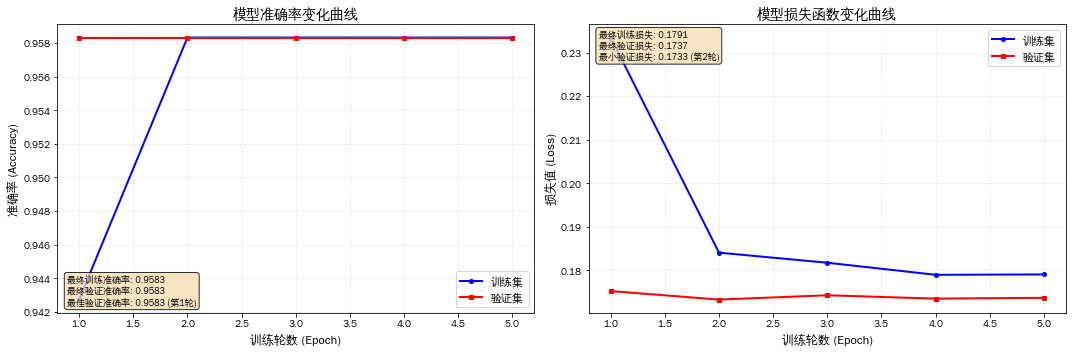


训练统计摘要：
总训练轮数: 5

【准确率】
  初始训练准确率: 0.9427
  最终训练准确率: 0.9583
  最终验证准确率: 0.9583
  最佳验证准确率: 0.9583 (第1轮)
  准确率差距: +0.0000

【损失值】
  初始训练损失: 0.2334
  最终训练损失: 0.1791
  最终验证损失: 0.1737
  最小验证损失: 0.1733 (第2轮)
  损失差距: -0.0054

【训练状态评估】
✅ 训练良好：模型泛化能力强


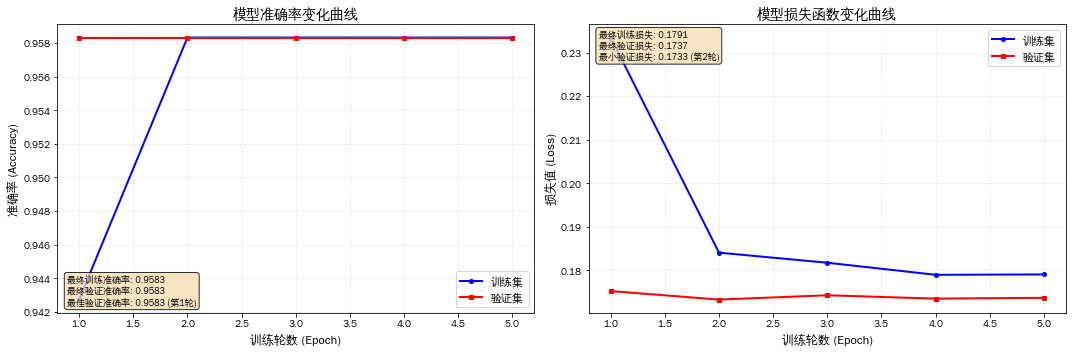

In [26]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.font_manager as fm

def setup_chinese_font():
    """自动设置中文字体"""
    # 查找系统中可用的中文字体
    chinese_fonts = []
    for font in fm.fontManager.ttflist:
        if any(name in font.name for name in ['SimHei', 'Microsoft YaHei', 'STHeiti', 'WenQuanYi', 'Noto Sans CJK']):
            chinese_fonts.append(font.name)
    
    if chinese_fonts:
        plt.rcParams['font.sans-serif'] = chinese_fonts
        print(f"使用中文字体: {chinese_fonts[0]}")
    else:
        print("未找到中文字体，使用默认设置")
        # 备用方案：使用英文标签
        return False
    
    plt.rcParams['axes.unicode_minus'] = False
    return True

# 设置字体
setup_chinese_font()

def create_chinese_plots(history, foldername='./'):
    """
    创建带中文标签的训练曲线图
    """
    # 检查可用的键
    print("可用的键:", list(history.history.keys()))
    
    # 确定准确率键名（兼容不同版本）
    if 'acc' in history.history:
        train_acc = history.history['acc']
        val_acc = history.history['val_acc']
        acc_key = 'acc'
    elif 'accuracy' in history.history:
        train_acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        acc_key = 'accuracy'
    else:
        print("错误：找不到准确率数据")
        return
    
    # 确定损失键名
    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    
    # 创建图形
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # ========== 左图：准确率曲线 ==========
    epochs = range(1, len(train_acc) + 1)
    
    ax1.plot(epochs, train_acc, 'b-', label='训练集', linewidth=2, marker='o', markersize=4)
    ax1.plot(epochs, val_acc, 'r-', label='验证集', linewidth=2, marker='s', markersize=4)
    ax1.set_title('模型准确率变化曲线', fontsize=14, fontweight='bold')
    ax1.set_xlabel('训练轮数 (Epoch)', fontsize=12)
    ax1.set_ylabel('准确率 (Accuracy)', fontsize=12)
    ax1.legend(loc='lower right', fontsize=11)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # 添加数值标注
    final_train_acc = train_acc[-1]
    final_val_acc = val_acc[-1]
    best_val_acc = max(val_acc)
    best_epoch = val_acc.index(best_val_acc) + 1
    
    text_str = f'最终训练准确率: {final_train_acc:.4f}\n最终验证准确率: {final_val_acc:.4f}\n最佳验证准确率: {best_val_acc:.4f} (第{best_epoch}轮)'
    ax1.text(0.02, 0.02, text_str, transform=ax1.transAxes, fontsize=9,
             verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # ========== 右图：损失曲线 ==========
    ax2.plot(epochs, train_loss, 'b-', label='训练集', linewidth=2, marker='o', markersize=4)
    ax2.plot(epochs, val_loss, 'r-', label='验证集', linewidth=2, marker='s', markersize=4)
    ax2.set_title('模型损失函数变化曲线', fontsize=14, fontweight='bold')
    ax2.set_xlabel('训练轮数 (Epoch)', fontsize=12)
    ax2.set_ylabel('损失值 (Loss)', fontsize=12)
    ax2.legend(loc='upper right', fontsize=11)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # 添加数值标注
    final_train_loss = train_loss[-1]
    final_val_loss = val_loss[-1]
    best_val_loss = min(val_loss)
    best_loss_epoch = val_loss.index(best_val_loss) + 1
    
    text_str2 = f'最终训练损失: {final_train_loss:.4f}\n最终验证损失: {final_val_loss:.4f}\n最小验证损失: {best_val_loss:.4f} (第{best_loss_epoch}轮)'
    ax2.text(0.02, 0.98, text_str2, transform=ax2.transAxes, fontsize=9,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(foldername + '训练曲线.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印详细统计
    print("\n" + "="*60)
    print("训练统计摘要：")
    print("="*60)
    print(f"总训练轮数: {len(train_acc)}")
    print(f"\n【准确率】")
    print(f"  初始训练准确率: {train_acc[0]:.4f}")
    print(f"  最终训练准确率: {final_train_acc:.4f}")
    print(f"  最终验证准确率: {final_val_acc:.4f}")
    print(f"  最佳验证准确率: {best_val_acc:.4f} (第{best_epoch}轮)")
    print(f"  准确率差距: {final_train_acc - final_val_acc:+.4f}")
    
    print(f"\n【损失值】")
    print(f"  初始训练损失: {train_loss[0]:.4f}")
    print(f"  最终训练损失: {final_train_loss:.4f}")
    print(f"  最终验证损失: {final_val_loss:.4f}")
    print(f"  最小验证损失: {best_val_loss:.4f} (第{best_loss_epoch}轮)")
    print(f"  损失差距: {final_val_loss - final_train_loss:+.4f}")
    
    # 判断训练状态
    print("\n【训练状态评估】")
    acc_gap = final_train_acc - final_val_acc
    loss_gap = final_val_loss - final_train_loss
    
    if acc_gap < 0.03 and loss_gap < 0.1:
        print("✅ 训练良好：模型泛化能力强")
    elif acc_gap > 0.1:
        print("⚠️ 可能过拟合：训练准确率远高于验证准确率")
    elif acc_gap < -0.03:
        print("⚠️ 异常：验证准确率高于训练准确率（可能使用了Dropout或数据增强）")
    else:
        print("✓ 训练正常")
    
    return fig

# 调用函数
create_chinese_plots(history, foldername='./')